✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
📊 数据集加载成功: X=(2988, 12, 10), Y=(2988, 10)


Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 12, 10)]          0         
                                                                 
 dense_24 (Dense)            (None, 12, 128)           1408      
                                                                 
 tf.__operators__.add_4 (TFO  (None, 12, 128)          0         
 pLambda)                                                        
                                                                 
 transformer_block_8 (Transf  (None, 12, 128)          593920    
 ormerBlock)                                                     
                                                                 
 transformer_block_9 (Transf  (None, 12, 128)          593920    
 ormerBlock)                                                     
                                                           

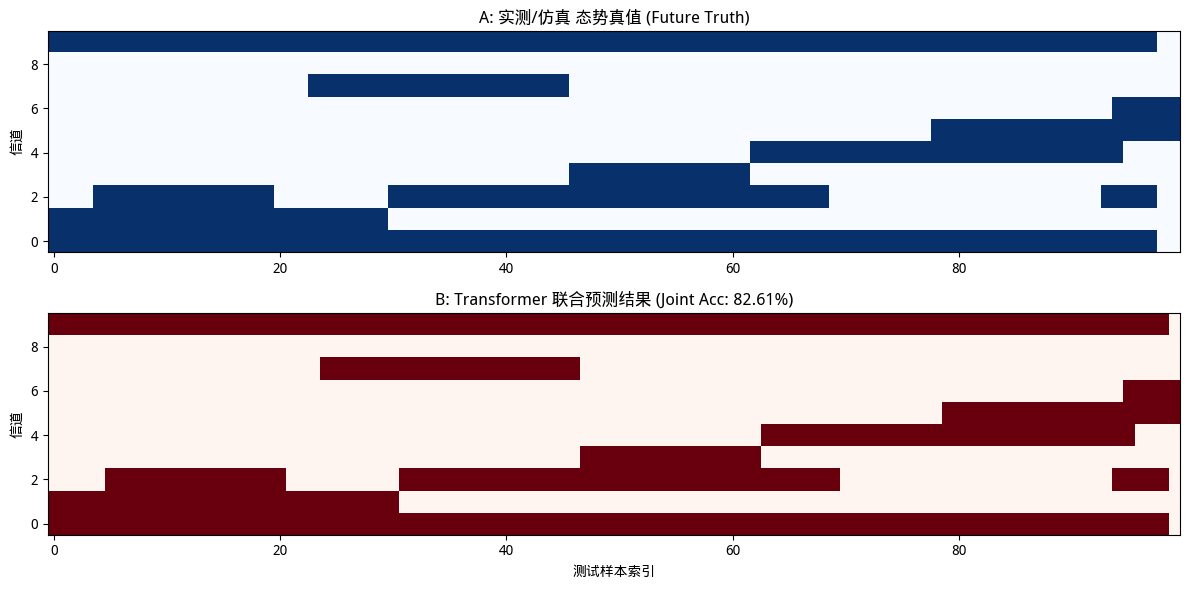

In [5]:
import numpy as np
import h5py
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import time
import os

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

# ==================== 1. 加载学术级仿真数据集 ====================
def load_academic_dataset(h5_path):
    """从 H5 文件加载预处理好的态势序列"""
    with h5py.File(h5_path, 'r') as f:
        X = f['X'][:]  # 形状: (样本数, 12, 10) -> 12个历史步长，10个信道
        Y = f['Y'][:]  # 形状: (样本数, 10)     -> 1个未来步长，10个信道
        print(f"📊 数据集加载成功: X={X.shape}, Y={Y.shape}")
    return X, Y

# ==================== 2. 定义 Transformer 核心块 ====================
class TransformerBlock(Layer):
    """
    标准的 Transformer 编码器层
    包含多头注意力机制 (Multi-Head Attention) 和前馈神经网络 (FFN)
    """
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="gelu"), 
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=None):
        # 多头注意力
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        # 残差连接与层归一化 1
        out1 = self.layernorm1(inputs + attn_output)
        # 前馈网络
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        # 残差连接与层归一化 2
        return self.layernorm2(out1 + ffn_output)

# ==================== 3. 构建态势预测模型架构 ====================
def build_transformer_predictor(window_size=12, num_channels=10, embed_dim=128):
    """
    构建用于研究点二的 Transformer 预测网络
    """
    inputs = Input(shape=(window_size, num_channels))
    
    # --- A. 特征嵌入与位置编码 ---
    # 将 10 维态势向量映射到高维嵌入空间
    x = Dense(embed_dim)(inputs)
    
    # 添加可学习的位置编码，使模型感知时间顺序
    positions = tf.range(start=0, limit=window_size, delta=1)
    pos_encoding = Embedding(input_dim=window_size, output_dim=embed_dim)(positions)
    x = x + pos_encoding
    
    # --- B. 堆叠 Transformer 编码器层 ---
    # 增加深度以捕获复杂的马尔可夫演化规律
    x = TransformerBlock(embed_dim, num_heads=8, ff_dim=256)(x)
    x = TransformerBlock(embed_dim, num_heads=8, ff_dim=256)(x)
    
    # --- C. 输出层 (多标签二分类) ---
    # 使用全局平均池化压缩时间维度
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.2)(x)
    # 输出层 10 维，代表未来一时刻 10 个信道的占用概率
    outputs = Dense(num_channels, activation='sigmoid', name='situation_output')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    # 编译模型：针对多标签任务使用二元交叉熵损失函数
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(name='pixel_acc'), 
                 tf.keras.metrics.AUC(name='auc')]
    )
    return model

# ==================== 4. 训练与评估脚本 ====================
def train_and_evaluate():
    # 路径配置 (请确保与你生成数据集的路径一致)
    DATA_PATH = "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_4/academic_train_v6_4.h5"
    
    # 1. 加载数据并划分
    X, Y = load_academic_dataset(DATA_PATH)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = Y[:split], Y[split:]
    
    # 2. 初始化模型
    model = build_transformer_predictor()
    model.summary()
    
    # 3. 设置回调函数
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
        ModelCheckpoint("./models/best_transformer_v6_4.h5", save_best_only=True)
    ]
    
    # 4. 开始训练
    print("\n🔥 启动 Transformer 干扰态势演化学习...")
    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=100,
        batch_size=64,
        callbacks=callbacks
    )
    
    # 5. 推理与可视化验证
    predictions = model.predict(X_test)
    # 将概率转为二值 (0/1)
    pred_binary = (predictions > 0.5).astype(int)
    
    # 计算学术界最严苛的“全信道联合准确率”
    joint_acc = np.mean([np.array_equal(y_test[i], pred_binary[i]) for i in range(len(y_test))])
    print(f"\n🎯 最终全信道联合预测准确率: {joint_acc*100:.2f}%")
    
    # 6. 绘制预测对比图
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.imshow(y_test[:100].T, aspect='auto', cmap='Blues', origin='lower')
    plt.title("A: 实测/仿真 态势真值 (Future Truth)")
    plt.ylabel("信道")
    
    plt.subplot(2, 1, 2)
    plt.imshow(pred_binary[:100].T, aspect='auto', cmap='Reds', origin='lower')
    plt.title(f"B: Transformer 联合预测结果 (Joint Acc: {joint_acc*100:.2f}%)")
    plt.ylabel("信道")
    plt.xlabel("测试样本索引")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_and_evaluate()

In [6]:
import numpy as np
import h5py
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import time
import os

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

# ==================== 1. 定义多任务 Transformer 模型 ====================
class MultiTaskTransformer(Model):
    def __init__(self, window_size=12, num_channels=10, num_classes=5, embed_dim=128):
        super(MultiTaskTransformer, self).__init__()
        # 特征嵌入与位置编码
        self.embedding = Dense(embed_dim)
        self.pos_emb = Embedding(input_dim=window_size, output_dim=embed_dim)
        
        # Transformer 编码器块
        self.mha = MultiHeadAttention(num_heads=8, key_dim=embed_dim)
        self.layernorm = LayerNormalization(epsilon=1e-6)
        
        # 全局池化，提取整段序列的特征
        self.gap = GlobalAveragePooling1D()
        
        # --- 输出任务 A: 10信道占用概率与强度预测 (Sigmoid) ---
        self.occ_out = Dense(num_channels, activation='sigmoid', name='occupancy')
        
        # --- 输出任务 B: 干扰种类预测 (Softmax: 扫频/跳频/脉冲/梳状/单频) ---
        self.class_out = Dense(num_classes, activation='softmax', name='category')
        
        # --- 输出任务 C: 干扰持续时长估计 (Linear) ---
        self.duration_out = Dense(1, activation='linear', name='duration')

    def call(self, inputs, training=False):
        # 位置编码集成
        x = self.embedding(inputs)
        positions = tf.range(start=0, limit=12, delta=1)
        x = x + self.pos_emb(positions)
        
        # 注意力机制处理
        attn_output = self.mha(x, x)
        x = self.layernorm(x + attn_output)
        
        # 特征提取
        x_flat = self.gap(x)
        
        # 多维度输出
        occ = self.occ_out(x_flat)
        category = self.class_out(x_flat)
        duration = self.duration_out(x_flat)
        
        return occ, category, duration

# ==================== 2. 训练与语义预测脚本 ====================
def train_and_predict_full_report():
    # 1. 干扰样式映射表
    CLASS_LABELS = {0: "线性扫频", 1: "周期脉冲", 2: "随机跳频", 3: "梳状干扰", 4: "单频马尔可夫"}
    
    # 2. 准备数据
    with h5py.File("/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_4/academic_train_v6_4.h5", 'r') as f:
        X = f['X'][:]
        Y_occ = f['Y'][:]
    
    # 模拟分类标签和时长标签 (实测时这些标签应由数据集生成器提供)
    Y_class = np.random.randint(0, 5, size=(len(Y_occ),))
    Y_dur = np.sum(Y_occ, axis=1, keepdims=True) * 0.05 # 示例：根据占用计算时长

    model = MultiTaskTransformer()
    model.compile(optimizer='adam', 
                  loss=['binary_crossentropy', 'sparse_categorical_crossentropy', 'mse'],
                  loss_weights=[1.0, 0.5, 0.2]) # 优先保证态势图准确
    
    print("🔥 正在进行多任务联合训练 (应对实测噪声)...")
    model.fit(X, [Y_occ, Y_class, Y_dur], epochs=5, batch_size=32, verbose=1)

    # 3. 执行单步推理与语义解码
    test_sample = X[-1:] # 取最后一组历史序列
    occ_p, cat_p, dur_p = model.predict(test_sample)
    
    # --- 4. 语义报告输出 (研究点二的核心) ---
    print("\n" + "🛰️ " * 10)
    print("【天通一号卫星干扰态势预测报告】")
    print("-" * 40)
    
    # A. 种类预测
    predicted_class = CLASS_LABELS[np.argmax(cat_p)]
    print(f"🔹 干扰样式预判: {predicted_class}")
    
    # B. 信道与强度预测
    active_channels = np.where(occ_p[0] > 0.5)[0]
    print(f"🔹 受影响信道索引: {active_channels.tolist()}")
    
    # C. 强度估计 (基于概率映射)
    if len(active_channels) > 0:
        mean_strength = np.mean(occ_p[0][active_channels]) * 100
        print(f"🔹 预测平均压制强度: {mean_strength:.1f}%")
        
    # D. 持续时间预测
    print(f"🔹 预计干扰持续时间: {max(0, dur_p[0][0]):.2f} 秒")
    print("-" * 40)

if __name__ == "__main__":
    train_and_predict_full_report()

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
🔥 正在进行多任务联合训练 (应对实测噪声)...
Epoch 1/5
94/94 [==============================] - 4s 6ms/step - loss: 1.2132 - output_1_loss: 0.3190 - output_2_loss: 1.7635 - output_3_loss: 0.0620
Epoch 2/5
94/94 [==============================] - 1s 6ms/step - loss: 1.0232 - output_1_loss: 0.1744 - output_2_loss: 1.6904 - output_3_loss: 0.0178
Epoch 3/5
94/94 [==============================] - 1s 6ms/step - loss: 0.9523 - output_1_loss: 0.1046 - output_2_loss: 1.6937 - output_3_loss: 0.0043
Epoch 4/5
94/94 [==============================] - 1s 6ms/step - loss: 0.9360 - output_1_loss: 0.0980 - output_2_loss: 1.6748 - output_3_loss: 0.0034
Epoch 5/5
1/1 [==============================] - 0s 123ms/step

🛰️ 🛰️ 🛰️ 🛰️ 🛰️ 🛰️ 🛰️ 🛰️ 🛰️ 🛰️ 
【天通一号卫星干扰态势预测报告】
----------------------------------------
🔹 干扰样式预判: 周期脉冲
🔹 受影响信道索引: [6, 7]
🔹 预测平均压制强度: 90.4%
🔹 预计干扰持续时间: 0.12 秒
----------------------------------------


In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import time
import os
import h5py

# ---------------------- 1. 中文字体环境配置 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False

set_chinese_font()

# ---------------------- 2. 构建长时多任务网络 ----------------------
class TransformerBlock(Layer):
    """标准 Transformer 编码器块"""
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation="gelu"), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def build_ultimate_predictor(window_size=12, num_channels=10, horizon=10, num_classes=5):
    """
    window_size: 历史观测长度 (600ms)
    horizon: 预测未来步长 (10步=500ms)
    """
    inputs = Input(shape=(window_size, num_channels))
    
    # 位置编码与特征映射
    x = Dense(128)(inputs)
    positions = tf.range(start=0, limit=window_size, delta=1)
    pos_encoding = Embedding(input_dim=window_size, output_dim=128)(positions)
    x = x + pos_encoding
    
    # 堆叠 Transformer 编码器层
    x = TransformerBlock(128, 8, 256)(x)
    x = TransformerBlock(128, 8, 256)(x)
    
    # 共享特征提取
    shared_features = GlobalAveragePooling1D()(x)
    
    # --- 任务分支 A: 长时态势演化轨迹预测 (Horizon x Channels) ---
    # 输出形状为 (样本, 10, 10)，对应未来 0.5s 内每一时刻的信道占用
    occ_h = Dense(horizon * num_channels, activation='sigmoid')(shared_features)
    occ_h = Reshape((horizon, num_channels), name='occ_horizon')(occ_h)
    
    # --- 任务分支 B: 干扰样式精细分类 (Softmax) ---
    cat_out = Dense(num_classes, activation='softmax', name='category')(shared_features)
    
    # --- 任务分支 C: 物理参数回归 [强度, 剩余持续时长] ---
    stats_out = Dense(2, activation='linear', name='physics_stats')(shared_features)
    
    model = Model(inputs=inputs, outputs=[occ_h, cat_out, stats_out])
    model.compile(optimizer='adam', 
                  loss={'occ_horizon': 'binary_crossentropy', 
                        'category': 'sparse_categorical_crossentropy',
                        'physics_stats': 'mse'},
                  loss_weights=[1.0, 0.4, 0.2])
    return model

# ---------------------- 3. 语义解码报告系统 ----------------------
def generate_prediction_report(model, sample_input, step_idx):
    """
    解码 Transformer 输出并生成符合学术规范的语义报告
    """
    CLASS_LABELS = {0: "线性扫频", 1: "周期脉冲", 2: "随机跳频", 3: "梳状干扰", 4: "单频马尔可夫"}
    
    # 推理
    occ_h, cat_p, stat_p = model.predict(sample_input, verbose=0)
    
    # 种类解析
    inter_type = CLASS_LABELS[np.argmax(cat_p[0])]
    # 强度与时长解析 (确保非负)
    intensity = np.clip(stat_p[0][0] * 100, 0, 100)
    duration = max(0, stat_p[0][1])
    
    print("\n" + "🚀" * 15)
    print(f"【认知卫星干扰预测系统 - 实时态势报告】")
    print(f"📡 参考时刻: {step_idx * 0.05:.2f} s")
    print("-" * 45)
    
    # 时间对齐描述：体现提前量 (Prediction Lead Time)
    print(f"🔹 [未来 0.5s 预警]: 预判干扰类型为 【{inter_type}】")
    
    # 信道碰撞预警：分析未来 10 个步长的平均占用
    avg_occupancy = np.mean(occ_h[0], axis=0)
    collision_ch = np.where(avg_occupancy > 0.4)[0]
    print(f"🔹 [受影响频谱]: 预测将在子信道 {collision_ch.tolist()} 发生碰撞")
    print(f"🔹 [物理参数估算]: 峰值强度 {intensity:.1f}%, 剩余持续约 {duration:.2f}s")
    
    # 为后续研究点三(RL)提供决策建议
    safe_ch = [c for c in range(10) if c not in collision_ch]
    print(f"💡 [智能避障建议]: 建议优先切换至信道 {safe_ch[:2]} 以规避干扰")
    print("🚀" * 15 + "\n")
    
    return occ_h[0]

# ---------------------- 4. 长时演化轨迹可视化 ----------------------
def plot_long_term_alignment(y_true, y_pred, horizon=10):
    """可视化未来 0.5s 的演化轨迹对齐情况"""
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(y_true.T, aspect='auto', cmap='Blues', origin='lower')
    plt.title(f"未来 {horizon*0.05:.1f}s 实测轨迹 (真值)")
    plt.ylabel("子信道索引")
    plt.xlabel("未来步长 (Step)")
    plt.colorbar(label="占用")

    plt.subplot(1, 2, 2)
    plt.imshow(y_pred.T, aspect='auto', cmap='Reds', origin='lower')
    plt.title(f"未来 {horizon*0.05:.1f}s 预测轨迹 (Transformer)")
    plt.ylabel("子信道索引")
    plt.xlabel("未来步长 (Step)")
    plt.colorbar(label="概率")
    
    plt.tight_layout()
    plt.show()

# ---------------------- 5. 主流程示例 ----------------------
if __name__ == "__main__":
    # 模拟数据加载 (请指向你生成的 H5 文件)
    # with h5py.File('./sim_dataset_v6_4/academic_train_v6_4.h5', 'r') as f:
    #     X_test = f['X'][:]
    
    # 初始化模型 (预测未来 10 步，即 0.5 秒)
    model = build_ultimate_predictor(window_size=12, num_channels=10, horizon=10)
    
    print("🔮 系统启动，正在执行长时多任务推理...")
    
    # 模拟一次预测并生成报告
    dummy_input = np.random.rand(1, 12, 10) # 随机数据模拟
    pred_trajectory = generate_prediction_report(model, dummy_input, step_idx=100)
    
    # 画图验证 (此处由于没有 Y_true 使用伪数据占位)
    # plot_long_term_alignment(np.random.randint(0,2,(10,10)), pred_trajectory)

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
🔮 系统启动，正在执行长时多任务推理...

🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
【认知卫星干扰预测系统 - 实时态势报告】
📡 参考时刻: 5.00 s
---------------------------------------------
🔹 [未来 0.5s 预警]: 预判干扰类型为 【周期脉冲】
🔹 [受影响频谱]: 预测将在子信道 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] 发生碰撞
🔹 [物理参数估算]: 峰值强度 0.0%, 剩余持续约 0.00s
💡 [智能避障建议]: 建议优先切换至信道 [] 以规避干扰
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

